# Prediccion de Zona de Destino -- NYC Yellow Taxi 2015-01

**Tarea 1 -- Sistemas Urbanos Inteligentes (ICT3115, 2026-1)**  
**Problema:** Clasificacion multiclase -- predecir la zona de destino (`DOLocationID`, hasta 265 clases)  
**Features:** tiempo de pickup + zona de origen (PULocationID) + metadata Census ACS del barrio de origen  
**Autores:** Nicolas Herrera y Vincent Metzker

> **Nota:** todas las features usadas son informacion disponible en el momento del pickup.

Este notebook tiene las siguientes secciones:
1. Carga de datos y preparacion
2. Analisis del target variable
3. Split y preprocesamiento
4. MLP base (sin embeddings)
5. MLP con embeddings (PULocationID como embedding)
6. Analisis de sobreajuste + regularizacion
7. AutoEncoder + MLP
8. Analisis critico final

## 0. Setup

In [ ]:
# para google colab CORRER EN T4 GPU SIEMPRE
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/tarea-1-sistemas-urbanos/data'

Mounted at /content/drive


In [ ]:
!pip install pandas pyarrow scikit-learn matplotlib seaborn

In [ ]:
import random, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, top_k_accuracy_score)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
SEED = 22041991

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

if torch.cuda.is_available():            DEVICE = 'cuda'
elif torch.backends.mps.is_available():  DEVICE = 'mps'
else:                                    DEVICE = 'cpu'

print('Dispositivo:', DEVICE)

Dispositivo: cuda


## 1. Carga y preparacion de datos

### 1.1 Cargar muestra

In [ ]:
df = pd.read_parquet(os.path.join(DATA_DIR, 'trips_sample_with_cats.parquet'))
print(f'Shape cargado: {df.shape}')
df.head(3)

Shape cargado: (300000, 48)


,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount,passenger_count,hour_sin,hour_cos,dow_sin,dow_cos,PU_Population,PU_MedianHouseholdIncome,PU_HousingUnits,PU_Transport_CarAlone_pct,PU_Transport_Carpool_pct,PU_Transport_PublicTransit_pct,PU_Transport_Walked_pct,PU_Transport_Bicycle_pct,PU_Transport_Other_pct,PU_Transport_WorkFromHome_pct,DO_Population,DO_MedianHouseholdIncome,DO_HousingUnits,DO_Transport_CarAlone_pct,DO_Transport_Carpool_pct,DO_Transport_PublicTransit_pct,DO_Transport_Walked_pct,DO_Transport_Bicycle_pct,DO_Transport_Other_pct,DO_Transport_WorkFromHome_pct,VendorID,RatecodeID,payment_type,store_and_fwd_flag,PULocationID,DOLocationID,PU_Borough_id,DO_Borough_id,hour,day_of_week,month,day_of_month,is_weekend,is_rush_hour,is_night,is_morning,is_afternoon,trip_duration
0,1.14,8.6,14.35,0.00,0.0,1.0,0.707107,0.707107,0.433884,-0.900969,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,2,1,2,0,161,50,0,0,3,3,1,15,0,0,1,0,0,6.133333
1,0.70,5.3,12.95,0.00,0.0,1.0,0.258819,-0.965926,-0.781832,0.623490,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1,1,0,0,246,90,0,0,11,6,1,18,1,0,0,1,0,6.066667
2,0.69,11.4,19.38,3.23,0.0,1.0,0.500000,-0.866025,0.433884,-0.900969,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,1694251.0,106403.0,932314.0,5.2,1.1,51.0,18.3,3.1,3.2,18.1,2,1,1,0,113,234,0,0,10,3,1,15,0,0,0,1,0,11.933333


### 1.2 Agregar metadata Census si faltan

Si el parquet fue guardado antes de correr la seccion 4.7 del notebook de EDA,
los campos census y borough no estaran presentes -- este bloque los anade.

In [ ]:
if 'PU_Borough_id' not in df.columns:
    print('Columnas census no encontradas -- ejecutando join...')
    lookup = pd.read_csv(os.path.join(DATA_DIR, 'taxi_zone_lookup_enriched.csv'))
    drop_cols = ['Zone', 'service_zone']
    pu_lookup = (lookup.drop(columns=drop_cols, errors='ignore')
                 .add_prefix('PU_').rename(columns={'PU_LocationID': 'PULocationID'}))
    do_lookup = (lookup.drop(columns=drop_cols, errors='ignore')
                 .add_prefix('DO_').rename(columns={'DO_LocationID': 'DOLocationID'}))
    df = df.merge(pu_lookup, on='PULocationID', how='left')
    df = df.merge(do_lookup, on='DOLocationID', how='left')
    BOROUGH_MAP = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2,
                   'Bronx': 3, 'Staten Island': 4, 'EWR': 5}
    df['PU_Borough_id'] = df['PU_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
    df['DO_Borough_id'] = df['DO_Borough'].map(BOROUGH_MAP).fillna(6).astype(np.int8)
    df.drop(columns=['PU_Borough', 'DO_Borough'], inplace=True, errors='ignore')
    census_cols = [c for c in df.columns if c.startswith(('PU_', 'DO_'))
                   and c not in ('PU_Borough_id', 'DO_Borough_id')]
    df[census_cols] = df[census_cols].fillna(0)
    print('Join completado:', df.shape)
else:
    print('Columnas census ya presentes.')

Columnas census ya presentes.


### 1.3 Definir target y features

In [ ]:
TARGET = 'DOLocationID'

# Filtrar zonas raras (menos de MIN_SAMPLES viajes)
MIN_SAMPLES = 50
df['do_zone_idx'] = (df[TARGET] - 1).clip(0, 264).astype(np.int64)
zone_counts = df['do_zone_idx'].value_counts()
valid_zones  = zone_counts[zone_counts >= MIN_SAMPLES].index
df = df[df['do_zone_idx'].isin(valid_zones)].copy()

# Reindexar a indices consecutivos 0, 1, 2, ...
zone_remap = {old: new for new, old in enumerate(sorted(valid_zones))}
df['do_zone_idx'] = df['do_zone_idx'].map(zone_remap)
remap_inv  = {v: k+1 for k, v in zone_remap.items()}  # idx -> LocationID original
N_CLASSES  = len(valid_zones)

# Lookup de nombres de zona
zone_lookup = pd.read_csv(os.path.join(DATA_DIR, 'taxi_zone_lookup_enriched.csv'),
                           usecols=['LocationID', 'Zone', 'Borough'])
zone_lookup = zone_lookup.set_index('LocationID')

# Features numericas (disponibles en tiempo de pickup)
NUM_FEATS = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'PU_Population', 'PU_MedianHouseholdIncome', 'PU_HousingUnits',
    'PU_Transport_CarAlone_pct', 'PU_Transport_Carpool_pct',
    'PU_Transport_PublicTransit_pct', 'PU_Transport_Walked_pct',
    'PU_Transport_Bicycle_pct', 'PU_Transport_Other_pct',
    'PU_Transport_WorkFromHome_pct',
    'is_weekend', 'is_rush_hour', 'is_night', 'is_morning', 'is_afternoon',
    'hour', 'day_of_week', 'month',
]

CAT_FEATS_EMB = {
    'PULocationID':  265,
    'PU_Borough_id': 5,
}

CAT_ONEHOT = ['PU_Borough_id']

print(f'Zonas conservadas: {N_CLASSES} de 265')
print(f'Filas tras filtro: {len(df):,}')

Zonas conservadas: 174 de 265
Filas tras filtro: 298,346


## 2. Analisis del target

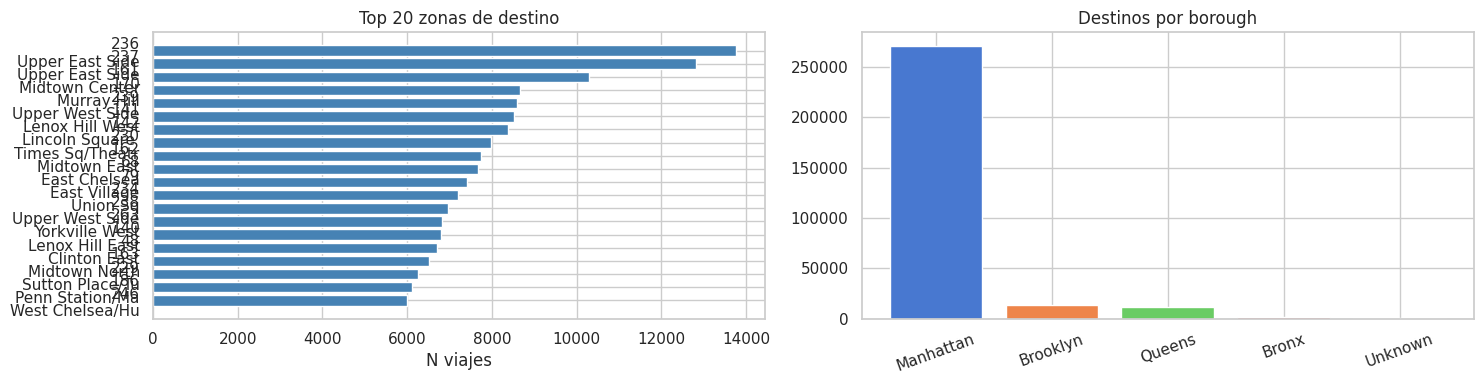

Top-1 zona = 4.6% de los viajes
Top-20 zonas cubren el 54.0% del total


In [ ]:
top20 = df[TARGET].value_counts().head(20)
top20_names = []
for loc in top20.index:
    name = zone_lookup.loc[loc,'Zone'][:15] if loc in zone_lookup.index else str(loc)
    top20_names.append(f'{loc}\n{name}')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].barh(top20_names[::-1], top20.values[::-1], color='steelblue')
axes[0].set_title('Top 20 zonas de destino')
axes[0].set_xlabel('N viajes')

BOROUGH_NAMES = {0:'Manhattan',1:'Brooklyn',2:'Queens',3:'Bronx',4:'Staten Island',5:'EWR',6:'Unknown'}
borough_dist  = df['DO_Borough_id'].value_counts().sort_index()
blabels = [BOROUGH_NAMES.get(i, str(i)) for i in borough_dist.index]
axes[1].bar(blabels, borough_dist.values, color=sns.color_palette('muted', len(borough_dist)))
axes[1].set_title('Destinos por borough')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print(f'Top-1 zona = {top20.iloc[0]/len(df)*100:.1f}% de los viajes')
print(f'Top-20 zonas cubren el {top20.sum()/len(df)*100:.1f}% del total')

## 3. Split y preprocesamiento

In [ ]:
df_onehot = df.copy()
df_emb    = df.copy()
df_ae     = df.copy()

y = df['do_zone_idx'].values

idx = np.arange(len(df))
tv_idx, test_idx = train_test_split(idx, test_size=0.15,
                                     stratify=y, random_state=SEED)
train_idx, val_idx = train_test_split(tv_idx, test_size=0.1765,
                                       stratify=y[tv_idx], random_state=SEED)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 208,834 | Val: 44,760 | Test: 44,752


### 3.1 Preprocesamiento MLP base (one-hot)

In [ ]:
df_onehot_enc = pd.get_dummies(df_onehot, columns=CAT_ONEHOT, drop_first=False)
onehot_cols = [c for c in df_onehot_enc.columns
               if any(c.startswith(p+'_') for p in CAT_ONEHOT)]

features_base = NUM_FEATS + onehot_cols
X_base = df_onehot_enc[features_base].astype(np.float32).values
y_base = df_onehot_enc['do_zone_idx'].values

scaler_base = StandardScaler()
X_base[train_idx] = scaler_base.fit_transform(X_base[train_idx])
X_base[val_idx]   = scaler_base.transform(X_base[val_idx])
X_base[test_idx]  = scaler_base.transform(X_base[test_idx])

print(f'Features baseline: {X_base.shape[1]} | Clases: {N_CLASSES}')

Features baseline: 28 | Clases: 174


### 3.2 DataLoaders baseline

In [ ]:
BATCH_SIZE = 256

def make_loader(X, y, idx, shuffle=True):
    Xt = torch.tensor(X[idx], dtype=torch.float32)
    yt = torch.tensor(y[idx], dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader_base = make_loader(X_base, y_base, train_idx)
val_loader_base   = make_loader(X_base, y_base, val_idx,   shuffle=False)
test_loader_base  = make_loader(X_base, y_base, test_idx,  shuffle=False)

xb, yb = next(iter(train_loader_base))
print('Batch X:', xb.shape, '| Batch y:', yb.shape)

Batch X: torch.Size([256, 28]) | Batch y: torch.Size([256])


## 4. MLP Base (sin embeddings)

Variables categoricas de baja cardinalidad (PU_Borough_id) con one-hot.  
PULocationID se excluye para no agregar cientos de dimensiones -- entra como embedding en la seccion 5.  
Con muchas clases de destino, la metrica principal es **Top-5 Accuracy** ademas de accuracy estandar.

In [ ]:
class MLPBase(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.3, n_classes=N_CLASSES):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model_base = MLPBase(input_dim=X_base.shape[1]).to(DEVICE)
print(model_base)
print(f'Parametros: {sum(p.numel() for p in model_base.parameters()):,}')

MLPBase(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=174, bias=True)
  )
)
Parametros: 60,782


In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits = model(Xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    for Xb, yb in loader:
        logits = model(Xb.to(DEVICE))
        y_scores.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(y_scores)

def plot_curves(train_vals, val_vals, metric='Loss', title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(train_vals, label='Train')
    plt.plot(val_vals,   label='Validacion')
    plt.xlabel('Epoca'); plt.ylabel(metric)
    plt.title(title or metric); plt.legend(); plt.tight_layout(); plt.show()

def eval_report(y_true, y_pred, y_scores, label=''):
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    top5  = top_k_accuracy_score(y_true, y_scores, k=5)
    top10 = top_k_accuracy_score(y_true, y_scores, k=10)
    print(f'=== {label} ===')
    print(f'  Accuracy:          {acc:.4f}')
    print(f'  Balanced Accuracy: {bacc:.4f}')
    print(f'  Top-5  Accuracy:   {top5:.4f}')
    print(f'  Top-10 Accuracy:   {top10:.4f}')
    return {'acc': acc, 'bacc': bacc, 'top5': top5, 'top10': top10}

In [ ]:
EPOCHS    = 60
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

hist_base = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_epoch(model_base, train_loader_base, criterion, optimizer)
    vl, va = eval_epoch(model_base,  val_loader_base,   criterion)
    scheduler.step()
    hist_base['train_loss'].append(tl); hist_base['val_loss'].append(vl)
    hist_base['train_acc'].append(ta);  hist_base['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

Epoch 001 | loss=4.1700 acc=0.049 | val_loss=4.0580 val_acc=0.056
Epoch 010 | loss=4.0520 acc=0.057 | val_loss=4.0423 val_acc=0.059
Epoch 020 | loss=4.0473 acc=0.058 | val_loss=4.0427 val_acc=0.058
Epoch 030 | loss=4.0429 acc=0.057 | val_loss=4.0400 val_acc=0.059
Epoch 040 | loss=4.0423 acc=0.058 | val_loss=4.0398 val_acc=0.058
Epoch 050 | loss=4.0392 acc=0.058 | val_loss=4.0397 val_acc=0.059
Epoch 060 | loss=4.0393 acc=0.058 | val_loss=4.0396 val_acc=0.058


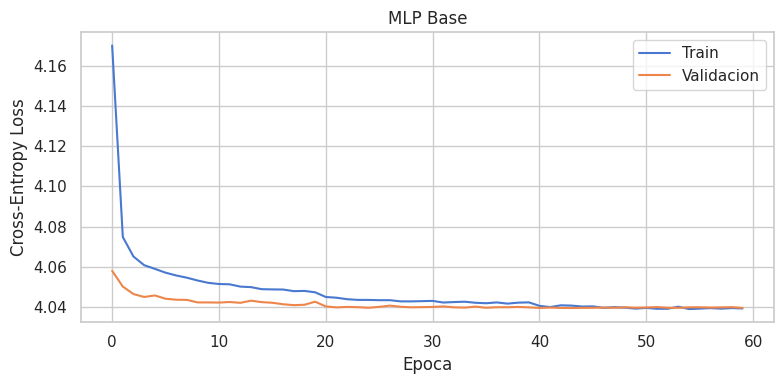

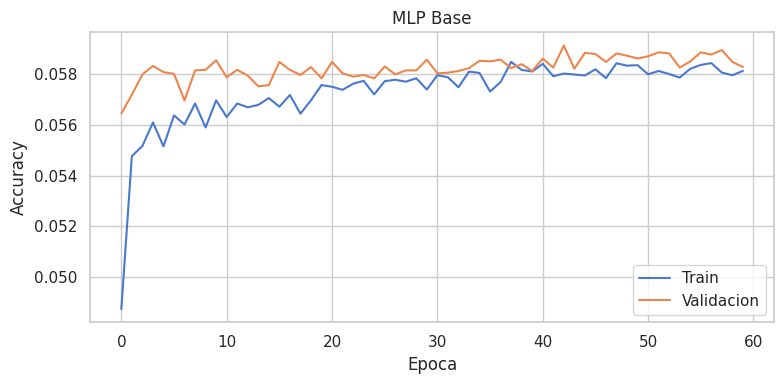

In [ ]:
plot_curves(hist_base['train_loss'], hist_base['val_loss'], 'Cross-Entropy Loss', 'MLP Base')
plot_curves(hist_base['train_acc'],  hist_base['val_acc'],  'Accuracy',           'MLP Base')

In [ ]:
y_true_base, y_pred_base, y_scores_base = get_preds(model_base, test_loader_base)
metrics_base = eval_report(y_true_base, y_pred_base, y_scores_base, 'MLP Base (test)')

from collections import Counter
errors = [(remap_inv[y_true_base[i]], remap_inv[y_pred_base[i]])
          for i in range(len(y_true_base)) if y_true_base[i] != y_pred_base[i]]
top_errors = Counter(errors).most_common(10)
print('\nTop 10 pares (real -> predicho) mas confundidos:')
for (real, pred), cnt in top_errors:
    rname = zone_lookup.loc[real,'Zone'] if real in zone_lookup.index else real
    pname = zone_lookup.loc[pred,'Zone'] if pred in zone_lookup.index else pred
    print(f'  {rname} -> {pname}: {cnt} veces')

=== MLP Base (test) ===
  Accuracy:          0.0569
  Balanced Accuracy: 0.0189
  Top-5  Accuracy:   0.2152
  Top-10 Accuracy:   0.3599

Top 10 pares (real -> predicho) mas confundidos:
  Upper East Side South -> Upper East Side North: 828 veces
  Upper West Side South -> Upper East Side North: 567 veces
  Upper East Side North -> Upper East Side South: 563 veces
  Lenox Hill West -> Upper East Side North: 558 veces
  Lincoln Square East -> Upper East Side North: 547 veces
  Midtown Center -> Upper East Side North: 544 veces
  Murray Hill -> Upper East Side North: 486 veces
  Upper West Side North -> Upper East Side North: 474 veces
  Times Sq/Theatre District -> Upper East Side North: 433 veces
  Midtown Center -> Upper East Side South: 429 veces


## 5. MLP con Embeddings

Con muchas zonas de destino, la zona de origen (`PULocationID`) es la senal geoespacial mas informativa.  
El embedding le permite al modelo aprender que zonas geograficamente cercanas son similares en comportamiento,  
sin necesitar cientos de dimensiones one-hot.

In [ ]:
for col, n_cats in CAT_FEATS_EMB.items():
    df_emb[col] = df_emb[col].clip(0, n_cats - 1).astype(np.int64)
df_emb['PULocationID'] = (df_emb['PULocationID'] - 1).clip(0, 264).astype(np.int64)

X_num_emb = df_emb[NUM_FEATS].astype(np.float32).values
X_cat_emb = df_emb[list(CAT_FEATS_EMB.keys())].astype(np.int64).values
y_emb     = df_emb['do_zone_idx'].values

scaler_emb = StandardScaler()
X_num_emb[train_idx] = scaler_emb.fit_transform(X_num_emb[train_idx])
X_num_emb[val_idx]   = scaler_emb.transform(X_num_emb[val_idx])
X_num_emb[test_idx]  = scaler_emb.transform(X_num_emb[test_idx])

print(f'X_num: {X_num_emb.shape} | X_cat: {X_cat_emb.shape}')

X_num: (298346, 22) | X_cat: (298346, 2)


In [ ]:
class EmbDataset(Dataset):
    def __init__(self, X_num, X_cat, y, idx):
        self.X_num = torch.tensor(X_num[idx], dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat[idx], dtype=torch.long)
        self.y     = torch.tensor(y[idx],     dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X_num[i], self.X_cat[i], self.y[i]

train_ds_emb = EmbDataset(X_num_emb, X_cat_emb, y_emb, train_idx)
val_ds_emb   = EmbDataset(X_num_emb, X_cat_emb, y_emb, val_idx)
test_ds_emb  = EmbDataset(X_num_emb, X_cat_emb, y_emb, test_idx)

train_loader_emb = DataLoader(train_ds_emb, batch_size=BATCH_SIZE, shuffle=True)
val_loader_emb   = DataLoader(val_ds_emb,   batch_size=512, shuffle=False)
test_loader_emb  = DataLoader(test_ds_emb,  batch_size=512, shuffle=False)

In [ ]:
def emb_dim(n_cats):
    return min(50, (n_cats + 1) // 2)

class MLPWithEmb(nn.Module):
    def __init__(self, num_dim, cat_vocab, hidden_dims=(256,128,64), dropout=0.3, n_classes=N_CLASSES):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(n, emb_dim(n)) for n in cat_vocab])
        total_emb = sum(emb_dim(n) for n in cat_vocab)
        layers = []
        prev = num_dim + total_emb
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
        x = torch.cat([x_num] + emb_out, dim=1)
        return self.net(x)

cat_vocabs = list(CAT_FEATS_EMB.values())
model_emb = MLPWithEmb(num_dim=X_num_emb.shape[1], cat_vocab=cat_vocabs).to(DEVICE)
print(model_emb)
print(f'Parametros: {sum(p.numel() for p in model_emb.parameters()):,}')

MLPWithEmb(
  (embs): ModuleList(
    (0): Embedding(265, 50)
    (1): Embedding(5, 3)
  )
  (net): Sequential(
    (0): Linear(in_features=75, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=174, bias=True)
  )
)
Parametros: 86,079


In [ ]:
def train_epoch_emb(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch_emb(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def get_preds_emb(model, loader):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    for xn, xc, yb in loader:
        logits = model(xn.to(DEVICE), xc.to(DEVICE))
        y_scores.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(y_scores)

In [ ]:
EPOCHS_EMB    = 60
optimizer_emb = optim.Adam(model_emb.parameters(), lr=1e-3)
scheduler_emb = optim.lr_scheduler.StepLR(optimizer_emb, step_size=20, gamma=0.5)

hist_emb = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS_EMB + 1):
    tl, ta = train_epoch_emb(model_emb, train_loader_emb, criterion, optimizer_emb)
    vl, va = eval_epoch_emb(model_emb, val_loader_emb, criterion)
    scheduler_emb.step()
    hist_emb['train_loss'].append(tl); hist_emb['val_loss'].append(vl)
    hist_emb['train_acc'].append(ta);  hist_emb['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

Epoch 001 | loss=4.0628 acc=0.062 | val_loss=3.8895 val_acc=0.075
Epoch 010 | loss=3.8610 acc=0.076 | val_loss=3.8313 val_acc=0.081
Epoch 020 | loss=3.8480 acc=0.078 | val_loss=3.8280 val_acc=0.082
Epoch 030 | loss=3.8369 acc=0.080 | val_loss=3.8229 val_acc=0.082
Epoch 040 | loss=3.8339 acc=0.080 | val_loss=3.8220 val_acc=0.083
Epoch 050 | loss=3.8291 acc=0.080 | val_loss=3.8213 val_acc=0.083
Epoch 060 | loss=3.8292 acc=0.080 | val_loss=3.8212 val_acc=0.083


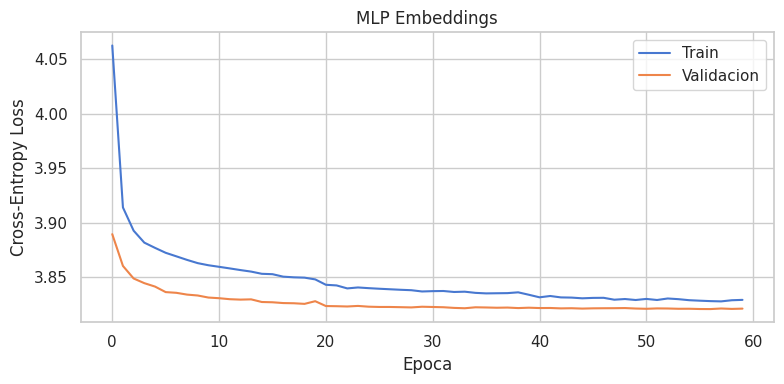

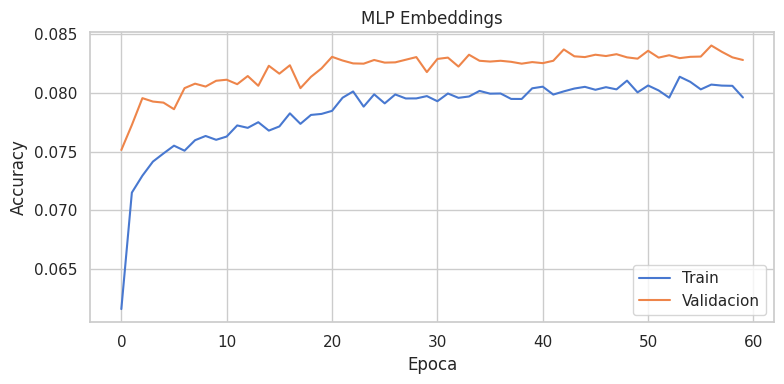

In [ ]:
plot_curves(hist_emb['train_loss'], hist_emb['val_loss'], 'Cross-Entropy Loss', 'MLP Embeddings')
plot_curves(hist_emb['train_acc'],  hist_emb['val_acc'],  'Accuracy',           'MLP Embeddings')

In [ ]:
y_true_emb, y_pred_emb, y_scores_emb = get_preds_emb(model_emb, test_loader_emb)
metrics_emb = eval_report(y_true_emb, y_pred_emb, y_scores_emb, 'MLP Embeddings (test)')

=== MLP Embeddings (test) ===
  Accuracy:          0.0833
  Balanced Accuracy: 0.0379
  Top-5  Accuracy:   0.2900
  Top-10 Accuracy:   0.4590


### 5.1 Visualizacion del espacio de embeddings de PULocationID

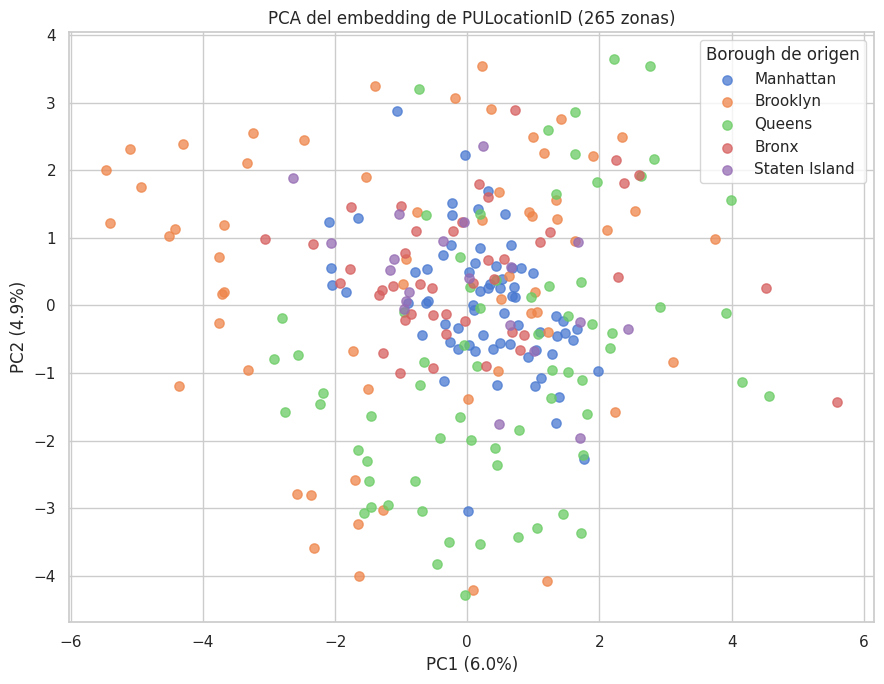

In [ ]:
from sklearn.decomposition import PCA

pu_weights = model_emb.embs[0].weight.data.cpu().numpy()
pca = PCA(n_components=2, random_state=SEED)
pu_2d = pca.fit_transform(pu_weights)

BOROUGH_MAP_COL = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2, 'Bronx': 3, 'Staten Island': 4}
colors = zone_lookup['Borough'].map(BOROUGH_MAP_COL).reindex(range(1, 266)).fillna(-1).values

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('muted', 5)
for bid, bname in {0:'Manhattan',1:'Brooklyn',2:'Queens',3:'Bronx',4:'Staten Island'}.items():
    mask = colors == bid
    ax.scatter(pu_2d[mask, 0], pu_2d[mask, 1], label=bname,
               color=palette[bid], alpha=0.75, s=45)

ax.set_title('PCA del embedding de PULocationID (265 zonas)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Borough de origen')
plt.tight_layout(); plt.show()

## 6. Analisis de sobreajuste y regularizacion

### 6.1 Analisis de curvas de entrenamiento

Las curvas de entrenamiento revelan un comportamiento inusual a primera vista: en el modelo con embeddings, la **loss de validacion es consistentemente menor que la de entrenamiento**, y la **accuracy de validacion supera a la de entrenamiento** durante casi todas las epocas. Esto no es overfitting -- es el efecto del **Dropout**, que apaga aleatoriamente neuronas durante el forward pass de entrenamiento pero esta inactivo en validacion. El modelo en validacion es efectivamente 'mas grande' que en entrenamiento, lo que explica la aparente inversion.

El modelo base muestra curvas train y val casi identicas y planas (~5.8% accuracy), lo que indica **underfitting**: la representacion one-hot sin PULocationID no captura suficiente estructura geoespacial para distinguir destinos. El modelo con embeddings supera claramente al base (~8% vs ~5.8%), confirmando que la representacion densa de las zonas de origen aporta informacion relevante.

Dado que no hay brecha creciente train/val, el problema actual no es overfitting sino capacidad de representacion. La regularizacion aqui cumple un rol preventivo: al aumentar la capacidad del modelo para buscar mejor performance, el riesgo de overfitting crece. A continuacion se entrena una variante con mayor capacidad y se evalua el efecto de dropout y weight decay.

### 6.2 MLP con embeddings regularizado (mayor capacidad + dropout aumentado)

In [ ]:
# Misma arquitectura y dropout que MLP Embeddings -- solo se agrega weight decay
# para aislar su efecto sobre el entrenamiento
model_reg = MLPWithEmb(
    num_dim=X_num_emb.shape[1],
    cat_vocab=cat_vocabs,
    hidden_dims=(256, 128, 64),   # identico a MLP Embeddings
    dropout=0.3,                  # identico a MLP Embeddings
    n_classes=N_CLASSES
).to(DEVICE)

optimizer_reg = optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-3)  # unica diferencia
scheduler_reg = optim.lr_scheduler.StepLR(optimizer_reg, step_size=20, gamma=0.5)

hist_reg = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS_EMB + 1):
    tl, ta = train_epoch_emb(model_reg, train_loader_emb, criterion, optimizer_reg)
    vl, va = eval_epoch_emb(model_reg, val_loader_emb, criterion)
    scheduler_reg.step()
    hist_reg['train_loss'].append(tl); hist_reg['val_loss'].append(vl)
    hist_reg['train_acc'].append(ta);  hist_reg['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

Epoch 001 | loss=4.0663 acc=0.062 | val_loss=3.9038 val_acc=0.076
Epoch 010 | loss=3.8947 acc=0.071 | val_loss=3.8594 val_acc=0.076
Epoch 020 | loss=3.8935 acc=0.071 | val_loss=3.8612 val_acc=0.075
Epoch 030 | loss=3.8817 acc=0.072 | val_loss=3.8491 val_acc=0.077
Epoch 040 | loss=3.8806 acc=0.073 | val_loss=3.8472 val_acc=0.078
Epoch 050 | loss=3.8724 acc=0.074 | val_loss=3.8418 val_acc=0.078
Epoch 060 | loss=3.8724 acc=0.075 | val_loss=3.8393 val_acc=0.080


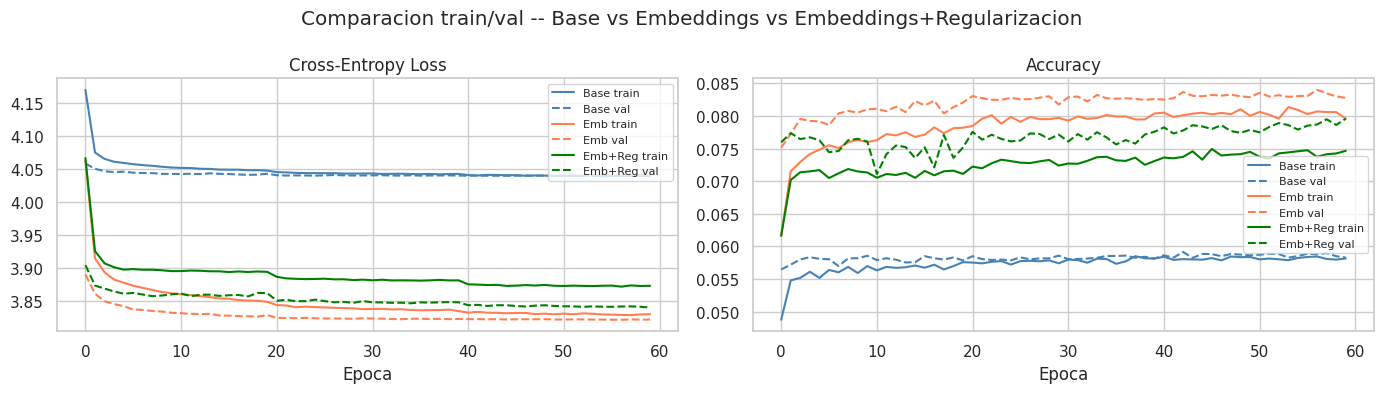

In [ ]:
# Comparacion de las tres curvas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_loss'], label='Base train',      lw=1.5, color='steelblue')
axes[0].plot(hist_base['val_loss'],   label='Base val',        lw=1.5, color='steelblue', ls='--')
axes[0].plot(hist_emb['train_loss'],  label='Emb train',       lw=1.5, color='coral')
axes[0].plot(hist_emb['val_loss'],    label='Emb val',         lw=1.5, color='coral',     ls='--')
axes[0].plot(hist_reg['train_loss'],  label='Emb+Reg train',   lw=1.5, color='green')
axes[0].plot(hist_reg['val_loss'],    label='Emb+Reg val',     lw=1.5, color='green',     ls='--')
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoca'); axes[0].legend(fontsize=8)

axes[1].plot(hist_base['train_acc'],  label='Base train',      lw=1.5, color='steelblue')
axes[1].plot(hist_base['val_acc'],    label='Base val',        lw=1.5, color='steelblue', ls='--')
axes[1].plot(hist_emb['train_acc'],   label='Emb train',       lw=1.5, color='coral')
axes[1].plot(hist_emb['val_acc'],     label='Emb val',         lw=1.5, color='coral',     ls='--')
axes[1].plot(hist_reg['train_acc'],   label='Emb+Reg train',   lw=1.5, color='green')
axes[1].plot(hist_reg['val_acc'],     label='Emb+Reg val',     lw=1.5, color='green',     ls='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoca'); axes[1].legend(fontsize=8)

plt.suptitle('Comparacion train/val -- Base vs Embeddings vs Embeddings+Regularizacion')
plt.tight_layout(); plt.show()

In [ ]:
y_true_reg, y_pred_reg, y_scores_reg = get_preds_emb(model_reg, test_loader_emb)
metrics_reg = eval_report(y_true_reg, y_pred_reg, y_scores_reg, 'MLP Emb + Regularizacion (test)')

=== MLP Emb + Regularizacion (test) ===
  Accuracy:          0.0779
  Balanced Accuracy: 0.0270
  Top-5  Accuracy:   0.2849
  Top-10 Accuracy:   0.4512


### 6.3 Discusion

El tercer modelo es identico al MLP con embeddings en arquitectura (hidden_dims, dropout) -- la unica diferencia es el **weight decay** (`1e-3` vs sin penalizacion). Esto permite aislar su efecto: si las curvas train/val se acercan o las metricas de test mejoran, el weight decay esta siendo util; si las metricas bajan, esta penalizando demasiado y habria que reducirlo.

El **weight decay** equivale a regularizacion L2 sobre los parametros del modelo: en cada paso de gradiente se empuja levemente los pesos hacia cero, desincentivando que el modelo asigne demasiada importancia a cualquier feature o conexion individual. Es especialmente util cuando hay muchas clases con pocos ejemplos, como en este problema donde las zonas menos frecuentes tienen muy pocas muestras de entrenamiento.

## 7. AutoEncoder + MLP

El AutoEncoder se entrena sobre las **variables numericas** (`NUM_FEATS`) para aprender una representacion comprimida. El encoder resultante se congela y su salida (el cuello de botella `z`) se usa como entrada a un MLP clasificador.

Ajusta `BOTTLENECK_DIM` para explorar el trade-off entre compresion e informacion retenida.

In [ ]:
# ── Hiperparametro principal: dimension del cuello de botella ─────────────────
BOTTLENECK_DIM = 12   # <-- cambia esto para experimentar (ej: 8, 16, 32, 64)

AE_EPOCHS  = 40
MLP_EPOCHS = 60
AE_LR      = 1e-3
MLP_LR     = 1e-3

### 7.1 Preparar datos (solo numericas)

In [ ]:
X_ae = df_ae[NUM_FEATS].astype(np.float32).values
y_ae = df_ae['do_zone_idx'].values

scaler_ae = StandardScaler()
X_ae[train_idx] = scaler_ae.fit_transform(X_ae[train_idx])
X_ae[val_idx]   = scaler_ae.transform(X_ae[val_idx])
X_ae[test_idx]  = scaler_ae.transform(X_ae[test_idx])

def make_loader_ae(X, y, idx, shuffle=True):
    Xt = torch.tensor(X[idx], dtype=torch.float32)
    yt = torch.tensor(y[idx], dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader_ae = make_loader_ae(X_ae, y_ae, train_idx)
val_loader_ae   = make_loader_ae(X_ae, y_ae, val_idx,   shuffle=False)
test_loader_ae  = make_loader_ae(X_ae, y_ae, test_idx,  shuffle=False)

INPUT_DIM = X_ae.shape[1]
print(f'Input dim: {INPUT_DIM} | Bottleneck: {BOTTLENECK_DIM}')

Input dim: 22 | Bottleneck: 12


### 7.2 Definir AutoEncoder

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), bottleneck=BOTTLENECK_DIM, dropout=0.2):
        super().__init__()
        # Encoder
        enc, prev = [], input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        enc.append(nn.Linear(prev, bottleneck))
        self.encoder = nn.Sequential(*enc)
        # Decoder (espejo del encoder)
        dec, prev = [], bottleneck
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

ae = AutoEncoder(input_dim=INPUT_DIM).to(DEVICE)
print(ae)
print(f'Parametros AE: {sum(p.numel() for p in ae.parameters()):,}')

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=12, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=22, bias=True)
  )
)
Parametros AE: 23,970


### 7.3 Entrenar AutoEncoder

AE Epoch 001 | train_loss=0.1754 | val_loss=0.0248
AE Epoch 010 | train_loss=0.0415 | val_loss=0.0136
AE Epoch 020 | train_loss=0.0366 | val_loss=0.0056
AE Epoch 030 | train_loss=0.0352 | val_loss=0.0049
AE Epoch 040 | train_loss=0.0345 | val_loss=0.0045


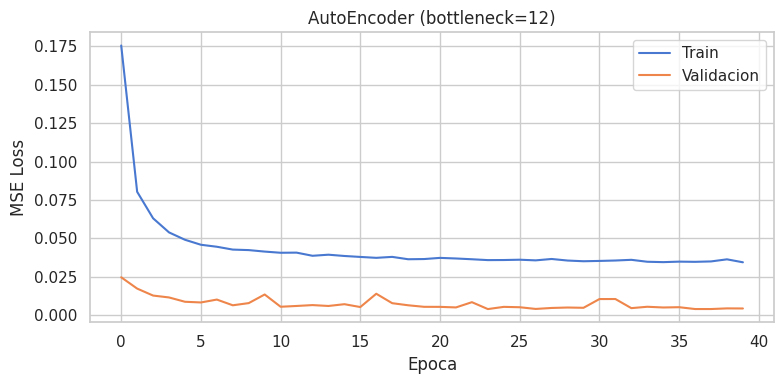

In [ ]:
ae_criterion  = nn.MSELoss()
ae_optimizer  = optim.Adam(ae.parameters(), lr=AE_LR)

hist_ae = {'train_loss': [], 'val_loss': []}

for epoch in range(1, AE_EPOCHS + 1):
    ae.train()
    batch_losses = []
    for Xb, _ in train_loader_ae:
        Xb = Xb.to(DEVICE)
        ae_optimizer.zero_grad()
        x_rec, _ = ae(Xb)
        loss = ae_criterion(x_rec, Xb)
        loss.backward(); ae_optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    ae.eval()
    with torch.no_grad():
        val_losses = []
        for Xb, _ in val_loader_ae:
            Xb = Xb.to(DEVICE)
            x_rec, _ = ae(Xb)
            val_losses.append(ae_criterion(x_rec, Xb).item())
    val_loss = np.mean(val_losses)

    hist_ae['train_loss'].append(train_loss)
    hist_ae['val_loss'].append(val_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f'AE Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

plot_curves(hist_ae['train_loss'], hist_ae['val_loss'], 'MSE Loss', f'AutoEncoder (bottleneck={BOTTLENECK_DIM})')

### 7.4 Congelar encoder y entrenar MLP clasificador

In [ ]:
# Congelar todos los parametros del AE
for param in ae.parameters():
    param.requires_grad = False

# MLP que recibe el bottleneck como entrada
mlp_ae = MLPBase(
    input_dim=BOTTLENECK_DIM,
    hidden_dims=(128, 64),
    dropout=0.3,
    n_classes=N_CLASSES
).to(DEVICE)

print(f'MLP sobre bottleneck -- input: {BOTTLENECK_DIM} dims')
print(f'Parametros entrenables: {sum(p.numel() for p in mlp_ae.parameters() if p.requires_grad):,}')

MLP sobre bottleneck -- input: 12 dims
Parametros entrenables: 21,614


In [ ]:
def train_epoch_ae(encoder, mlp, loader, criterion, optimizer):
    mlp.train(); encoder.eval()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        with torch.no_grad():
            z = encoder(Xb)
        optimizer.zero_grad()
        logits = mlp(z)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch_ae(encoder, mlp, loader, criterion):
    mlp.eval(); encoder.eval()
    total_loss, correct, total = 0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        z = encoder(Xb)
        logits = mlp(z)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def get_preds_ae(encoder, mlp, loader):
    mlp.eval(); encoder.eval()
    y_true, y_pred, y_scores = [], [], []
    for Xb, yb in loader:
        Xb = Xb.to(DEVICE)
        z = encoder(Xb)
        logits = mlp(z)
        y_scores.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred), np.vstack(y_scores)

Epoch 001 | loss=4.1756 acc=0.049 | val_loss=4.0659 val_acc=0.056
Epoch 010 | loss=4.0530 acc=0.057 | val_loss=4.0433 val_acc=0.058
Epoch 020 | loss=4.0470 acc=0.057 | val_loss=4.0420 val_acc=0.058
Epoch 030 | loss=4.0439 acc=0.058 | val_loss=4.0405 val_acc=0.058
Epoch 040 | loss=4.0423 acc=0.057 | val_loss=4.0409 val_acc=0.058
Epoch 050 | loss=4.0398 acc=0.058 | val_loss=4.0405 val_acc=0.058
Epoch 060 | loss=4.0395 acc=0.058 | val_loss=4.0406 val_acc=0.058


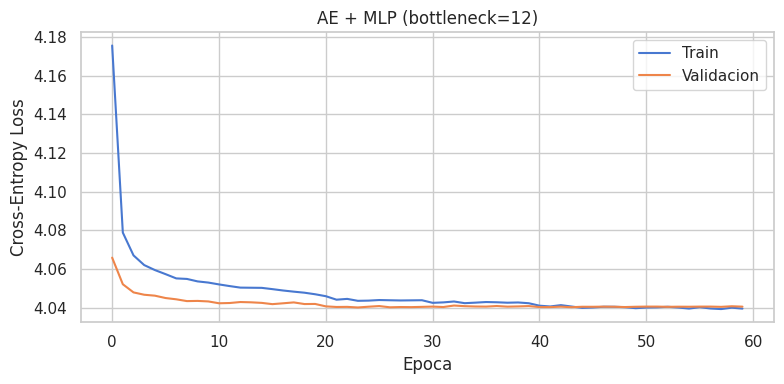

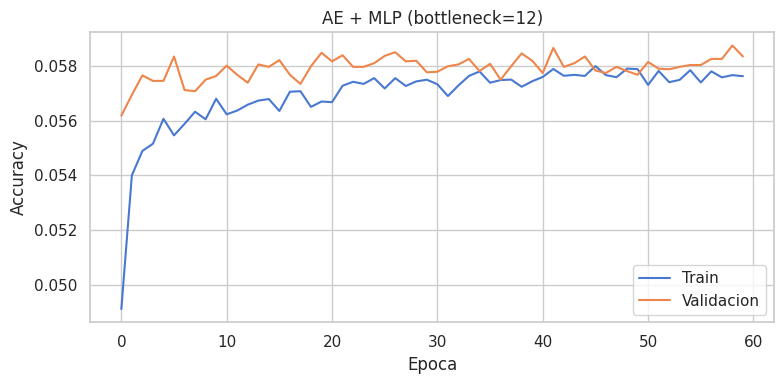

In [ ]:
mlp_ae_optimizer = optim.Adam(mlp_ae.parameters(), lr=MLP_LR)
mlp_ae_scheduler = optim.lr_scheduler.StepLR(mlp_ae_optimizer, step_size=20, gamma=0.5)

hist_mlp_ae = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, MLP_EPOCHS + 1):
    tl, ta = train_epoch_ae(ae.encoder, mlp_ae, train_loader_ae, criterion, mlp_ae_optimizer)
    vl, va = eval_epoch_ae(ae.encoder,  mlp_ae, val_loader_ae,   criterion)
    mlp_ae_scheduler.step()
    hist_mlp_ae['train_loss'].append(tl); hist_mlp_ae['val_loss'].append(vl)
    hist_mlp_ae['train_acc'].append(ta);  hist_mlp_ae['val_acc'].append(va)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}')

plot_curves(hist_mlp_ae['train_loss'], hist_mlp_ae['val_loss'], 'Cross-Entropy Loss',
           f'AE + MLP (bottleneck={BOTTLENECK_DIM})')
plot_curves(hist_mlp_ae['train_acc'],  hist_mlp_ae['val_acc'],  'Accuracy',
           f'AE + MLP (bottleneck={BOTTLENECK_DIM})')

In [ ]:
y_true_ae, y_pred_ae, y_scores_ae = get_preds_ae(ae.encoder, mlp_ae, test_loader_ae)
metrics_ae = eval_report(y_true_ae, y_pred_ae, y_scores_ae,
                          f'AE + MLP bottleneck={BOTTLENECK_DIM} (test)')

=== AE + MLP bottleneck=12 (test) ===
  Accuracy:          0.0560
  Balanced Accuracy: 0.0182
  Top-5  Accuracy:   0.2145
  Top-10 Accuracy:   0.3573


## 8. Analisis critico final

In [ ]:
results = pd.DataFrame({
    'Modelo':       ['MLP Base', 'MLP Embeddings', 'MLP Emb+Reg', f'AE+MLP (b={BOTTLENECK_DIM})'],
    'Accuracy':     [metrics_base['acc'],  metrics_emb['acc'],  metrics_reg['acc'],  metrics_ae['acc']],
    'Balanced Acc': [metrics_base['bacc'], metrics_emb['bacc'], metrics_reg['bacc'], metrics_ae['bacc']],
    'Top-5 Acc':    [metrics_base['top5'], metrics_emb['top5'], metrics_reg['top5'], metrics_ae['top5']],
    'Top-10 Acc':   [metrics_base['top10'],metrics_emb['top10'],metrics_reg['top10'],metrics_ae['top10']],
}).set_index('Modelo')
results.round(4)

,Accuracy,Balanced Acc,Top-5 Acc,Top-10 Acc
Modelo,,,,
MLP Base,0.0569,0.0189,0.2152,0.3599
MLP Embeddings,0.0833,0.0379,0.2900,0.4590
MLP Emb+Reg,0.0779,0.0270,0.2849,0.4512
AE+MLP (b=12),0.0560,0.0182,0.2145,0.3573


### Puntos a desarrollar:

1. **Dificultad del problema**: con muchas clases y distribucion desbalanceada (Manhattan concentra la mayoria de destinos), la accuracy cruda puede ser enganosa -- analizar Top-K Accuracy y Balanced Accuracy.
2. **MLP base vs embeddings**: el embedding de PULocationID mejora la prediccion porque aprende similitudes entre zonas. Analizar para que zonas fue mas util.
3. **Efecto de la regularizacion**: comparar las tres curvas -- si el modelo regularizado reduce la brecha train/val sin perder performance en test, la regularizacion fue efectiva.
4. **Visualizacion de embeddings**: zonas del mismo borough quedan agrupadas en PCA? Hay estructura geografica emergente?
5. **AutoEncoder**: el bottleneck comprime informacion util para clasificacion, o pierde senal importante?

# 9. Resultados Visuales Predicción

## 9.1 Probabilidades de destino desde zona 236

Manhattan Upper East Side North (zona más común). Al lado de central Park lol

Visualización guardada como 'prediccion_espacial_destino.png'


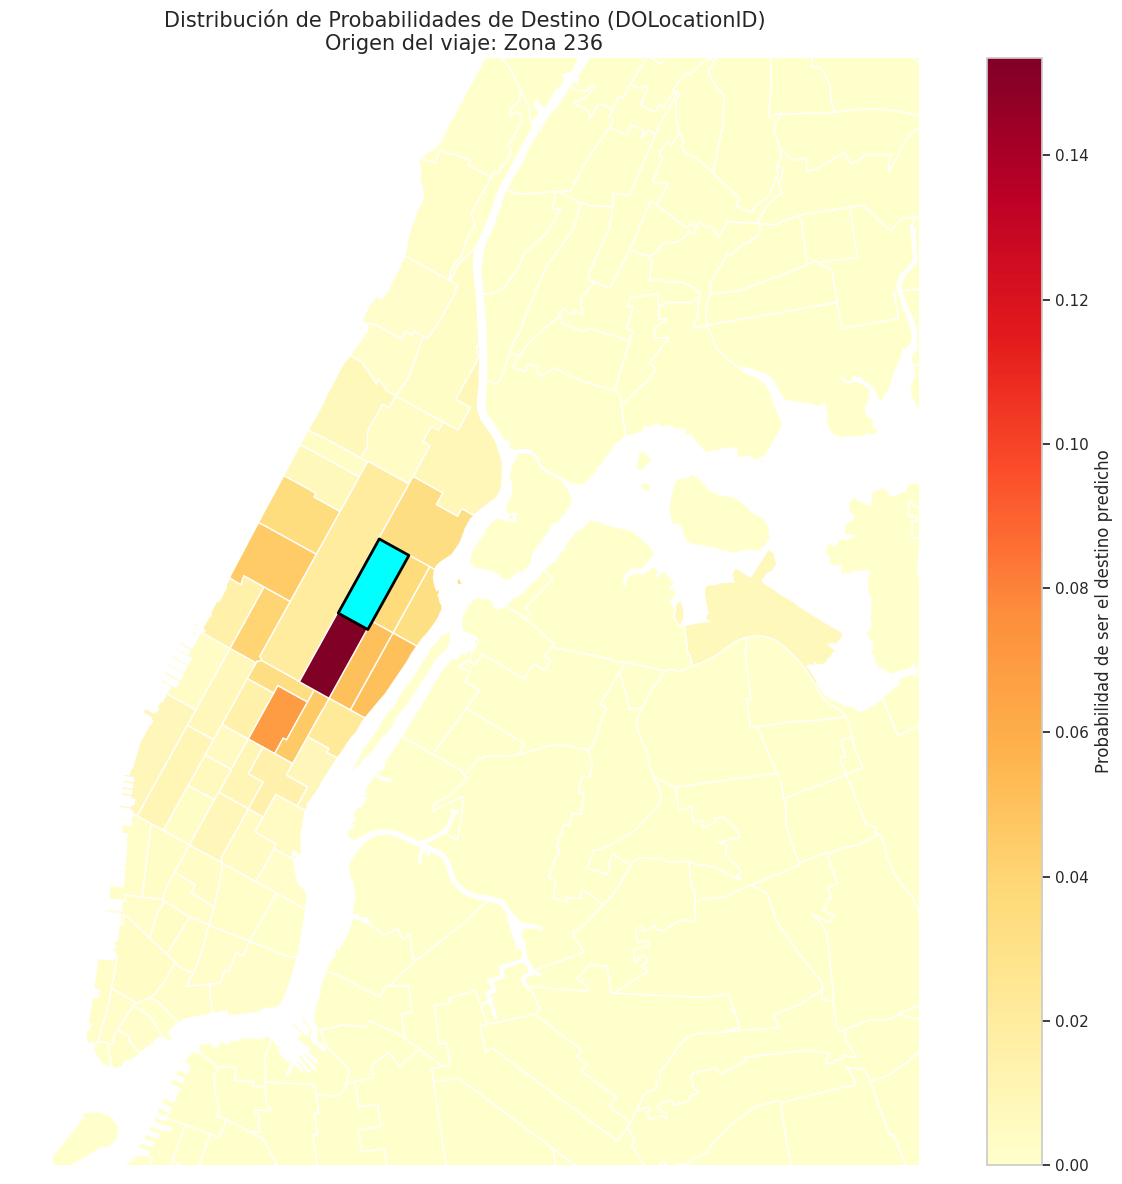

In [40]:
import geopandas as gpd

# 1. Definir la ruta relativa al archivo .shp
# Geopandas leerá automáticamente los archivos asociados (.dbf, .prj, etc.)
# Intenta subiendo un nivel
SHAPEFILE_PATH = os.path.join(DATA_DIR, 'taxi_zones.shp')

def visualizar_probabilidades_destino(model, dataset_emb, index, remap_inv, shp_path):
    """
    Toma un viaje del dataset, calcula probabilidades y las grafica en el mapa.
    """
    # Cargar el mapa de zonas de taxi
    try:
        nyc_map = gpd.read_file(shp_path)
    except Exception as e:
        print(f"Error al cargar el shapefile: {e}")
        return

    # Estandarizar el ID de la zona para el cruce (Join)
    # En el archivo oficial suele ser 'LocationID', pero verificamos por si acaso
    col_id = 'LocationID' if 'LocationID' in nyc_map.columns else 'location_i'
    nyc_map[col_id] = nyc_map[col_id].astype(int)

    # 2. Obtener los datos de entrada para un viaje específico
    x_num, x_cat, y_real = dataset_emb[index]

    # 3. Pasar por el modelo para obtener logits y luego probabilidades (Softmax)
    model.eval()
    with torch.no_grad():
        # Añadimos dimensión de batch [1, D]
        xn = x_num.unsqueeze(0).to(DEVICE)
        xc = x_cat.unsqueeze(0).to(DEVICE)
        logits = model(xn, xc)
        # Aplicamos Softmax para que la suma sea 1.0 (probabilidad)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    # 4. Crear DataFrame de probabilidades con el ID original (LocationID)
    # remap_inv mapea el índice [0-173] al ID original [1-265]
    prob_list = []
    for idx_clase, p in enumerate(probs):
        loc_id_original = remap_inv[idx_clase]
        prob_list.append({col_id: loc_id_original, 'prob_destino': p})

    df_probs = pd.DataFrame(prob_list)

    # 5. Unir la geometría con las probabilidades (Join espacial)
    mapa_final = nyc_map.merge(df_probs, on=col_id, how='left')
    mapa_final['prob_destino'] = mapa_final['prob_destino'].fillna(0)

    # 6. Graficar el mapa de calor
    fig, ax = plt.subplots(figsize=(14, 12))

    # Dibujar el fondo (toda la ciudad en gris claro)
    nyc_map.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

    # Dibujar las probabilidades con una escala de color (cmap)
    mapa_final.plot(
        column='prob_destino',
        ax=ax,
        legend=True,
        cmap='YlOrRd', # Amarillo a Rojo
        legend_kwds={'label': "Probabilidad de ser el destino predicho", 'orientation': "vertical"}
    )

    # Marcar el origen del viaje para contexto
    id_origen_original = int(x_cat[0].item()) + 1 # Ajuste si usaste clip(0, 264)
    origen_geom = nyc_map[nyc_map[col_id] == id_origen_original]
    if not origen_geom.empty:
        origen_geom.plot(ax=ax, color='cyan', edgecolor='black', linewidth=2, label='Zona de Origen')

    # --- NUEVA LÓGICA DE ZOOM ---
    # 1. Definimos un umbral de probabilidad para considerar una zona "relevante"
    # También incluimos la zona de origen para que siempre aparezca en el mapa
    umbral = 0.001
    zonas_relevantes = mapa_final[(mapa_final['prob_destino'] > umbral) |
                                  (mapa_final[col_id] == id_origen_original)]

    # 2. Obtenemos los límites (bounds) de estas zonas: [minx, miny, maxx, maxy]
    if not zonas_relevantes.empty:
        bounds = zonas_relevantes.total_bounds
        # Añadimos un pequeño margen (buffer) para que no quede tan apretado (aprox 10%)
        margin_x = (bounds[2] - bounds[0]) * 0.1
        margin_y = (bounds[3] - bounds[1]) * 0.1

        ax.set_xlim(bounds[0] - margin_x, bounds[2] + margin_x)
        ax.set_ylim(bounds[1] - margin_y, bounds[3] + margin_y)
    # ----------------------------

    plt.title(f"Distribución de Probabilidades de Destino (DOLocationID)\nOrigen del viaje: Zona {id_origen_original}", fontsize=15)
    ax.axis('off')
    plt.tight_layout()

    # Guardar la imagen para tu reporte
    plt.savefig('prediccion_espacial_destino.png', dpi=300)
    print("Visualización guardada como 'prediccion_espacial_destino.png'")


visualizar_probabilidades_destino(
    model=model_emb,
    dataset_emb=test_ds_emb,
    index=10,        # Cambia este número para ver distintos viajes (ej. 10, 50, 100)
    remap_inv=remap_inv,
    shp_path=SHAPEFILE_PATH
)
# 3. Forzar visualización en el notebook
plt.show()

## 9.2 Grafico de Flujo desde zona 236

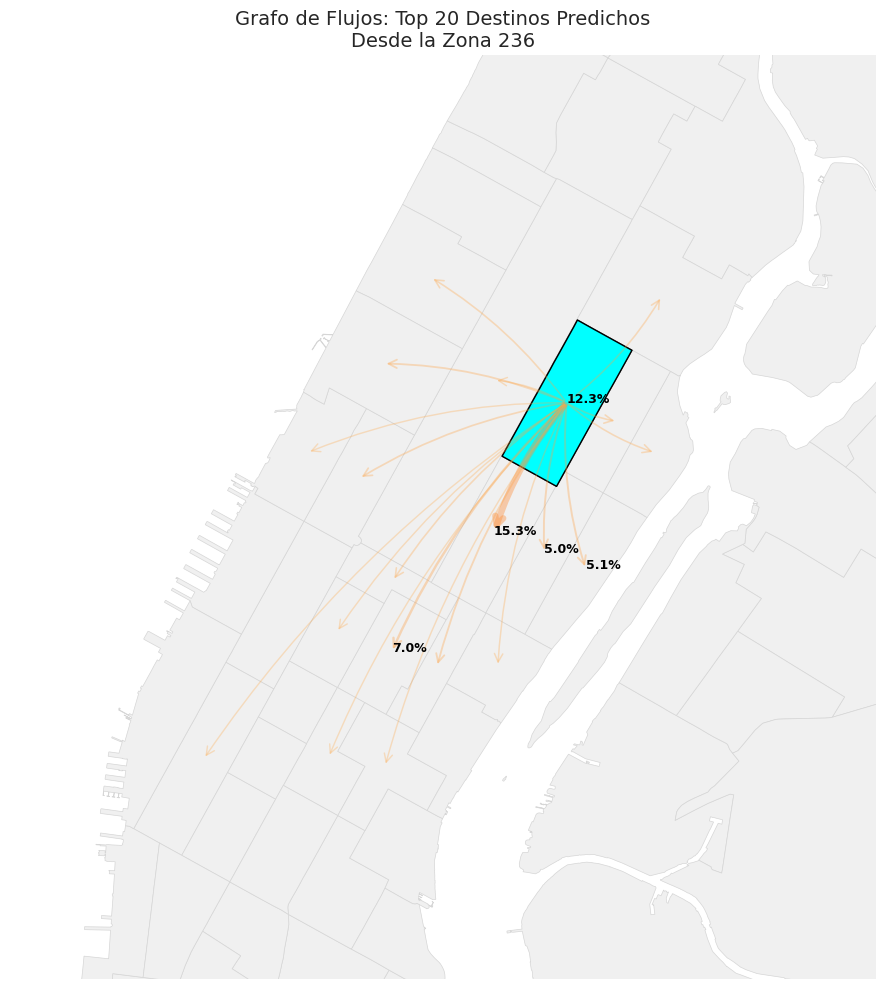

In [46]:
def graficar_grafo_flujos(model, dataset_emb, index, remap_inv, shp_path, top_k=10):
    # 1. Cargar el mapa y calcular centroides
    nyc_map = gpd.read_file(shp_path)
    col_id = 'LocationID' if 'LocationID' in nyc_map.columns else 'location_i'
    nyc_map[col_id] = nyc_map[col_id].astype(int)

    # Calcular centroides (lat/lon central de cada zona)
    # Usamos copy para evitar advertencias de SettingWithCopy
    centroids = nyc_map.copy()
    centroids['geometry'] = centroids.centroid

    # 2. Obtener predicciones del modelo
    model.eval()
    x_num, x_cat, _ = dataset_emb[index]
    with torch.no_grad():
        xn = x_num.unsqueeze(0).to(DEVICE)
        xc = x_cat.unsqueeze(0).to(DEVICE)
        logits = model(xn, xc)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0] # [cite: 678]

    # 3. Identificar Top K destinos
    # Mapeamos índices de la red a IDs originales de la TLC [cite: 210, 545]
    prob_data = []
    for i, p in enumerate(probs):
        prob_data.append({'idx': i, 'prob': p, col_id: remap_inv[i]})

    top_destinos = pd.DataFrame(prob_data).sort_values(by='prob', ascending=False).head(top_k)

    # 4. Obtener coordenadas del origen
    id_origen = int(x_cat[0].item()) + 1 # Ajuste de base 0 a ID original [cite: 570]
    origen_point = centroids[centroids[col_id] == id_origen].geometry.values[0]
    orig_x, orig_y = origen_point.x, origen_point.y

    # 5. Graficar
    fig, ax = plt.subplots(figsize=(12, 12))

    # Fondo: mapa de NYC difuminado
    nyc_map.plot(ax=ax, color='#f0f0f0', edgecolor='#d6d6d6', linewidth=0.5)

    # Dibujar la zona de origen resaltada
    nyc_map[nyc_map[col_id] == id_origen].plot(ax=ax, color='cyan', alpha=0.6, edgecolor='black')

    from matplotlib.patches import FancyArrowPatch

# ... (dentro de la función graficar_grafo_flujos) ...

    # 5. Graficar con flechas notorias
    for _, row in top_destinos.iterrows():
        dest_id = row[col_id]
        prob = row['prob']

        dest_row = centroids[centroids[col_id] == dest_id]
        if not dest_row.empty:
            dest_point = dest_row.geometry.values[0]
            dest_x, dest_y = dest_point.x, dest_point.y

            # --- MEJORA DE VISIBILIDAD ---
            # Grosor cuadrático: resalta mucho más los valores altos
            lw = 1 + (prob**2 * 150)

            # Opacidad dinámica
            alpha = 0.3 + (prob * 0.7)

            # Color: de naranja (bajo) a rojo oscuro (alto)
            color = plt.cm.YlOrRd(0.4 + prob * 0.6)

            # Dibujar Flecha "Notoria"
            arrow = FancyArrowPatch(
                (orig_x, orig_y), (dest_x, dest_y),
                connectionstyle="arc3,rad=0.1", # Curva ligera para evitar solapamiento
                arrowstyle='->,head_width=3,head_length=6',
                linestyle='-',
                linewidth=lw,
                edgecolor=color,
                alpha=alpha,
                zorder=5
            )
            ax.add_patch(arrow)

            # Añadir una pequeña etiqueta con el % si es muy probable
            if prob > 0.05:
                ax.text(dest_x, dest_y, f"{prob:.1%}", fontsize=9,
                        fontweight='bold', color='black', zorder=6)

    # Resaltar zona de origen
    nyc_map[nyc_map[col_id] == id_origen].plot(ax=ax, color='cyan', edgecolor='black', zorder=2)
    # Ajustar zoom al área de los flujos (opcional pero recomendado)
    # Reutilizamos la lógica de bounds para que se vea "bonito"
    ids_interes = top_destinos[col_id].tolist() + [id_origen]
    bounds = nyc_map[nyc_map[col_id].isin(ids_interes)].total_bounds
    margin = (bounds[2] - bounds[0]) * 0.2
    ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
    ax.set_ylim(bounds[1] - margin, bounds[3] + margin)

    plt.title(f"Grafo de Flujos: Top {top_k} Destinos Predichos\nDesde la Zona {id_origen}", fontsize=14)
    ax.axis('off')
    plt.show()

#Ejecución
graficar_grafo_flujos(model_emb, test_ds_emb, 10, remap_inv, SHAPEFILE_PATH, top_k=20)